In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np, json, joblib
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import r2_score, root_mean_squared_error

OUT_DIR = "/content/drive/MyDrive/Final_RUn/preprocessed_panel"

X_train_2d = np.load(f"{OUT_DIR}/X_train_2d.npy")   # (48056, 288)
X_test_2d  = np.load(f"{OUT_DIR}/X_test_2d.npy")     # (12028, 288)
y_train    = np.load(f"{OUT_DIR}/y_train.npy")
y_test     = np.load(f"{OUT_DIR}/y_test.npy")
meta = json.load(open(f"{OUT_DIR}/meta.json"))
T_RANGE = meta["target_range"]   # για μετατροπη normalized RMSE -> kW

print("train:", X_train_2d.shape, "test:", X_test_2d.shape)

train: (48056, 288) test: (12028, 288)


In [ ]:
zs_chk = StandardScaler().fit(X_train_2d)
svr_singh = SVR(kernel="rbf", C=1.0, gamma=0.1, epsilon=0.1)
svr_singh.fit(zs_chk.transform(X_train_2d[:15000]), y_train[:15000])
pred = svr_singh.predict(zs_chk.transform(X_test_2d))
print("Singh-params R2:", round(r2_score(y_test, pred), 4))

Singh-params R2: 0.1159


In [ ]:
GS_N = 5000
gs_idx = np.linspace(0, len(X_train_2d) - 1, GS_N).astype(int)   # ομοιομορφα στον χρονο
Xg, yg = X_train_2d[gs_idx], y_train[gs_idx]

zscaler = StandardScaler().fit(Xg)     # z-score πανω στην ηδη MinMax εισοδο
Xg_z = zscaler.transform(Xg)

param_grid = {
    "C":       [0.5, 1, 2, 5, 10, 50],
    "gamma":   [0.0001, 0.0005, 0.001, 0.005, 0.01, 0.1],
    "epsilon": [0.001, 0.005, 0.01, 0.05],
}

gs = GridSearchCV(
    SVR(kernel="rbf"), param_grid,
    scoring="neg_root_mean_squared_error",
    cv=TimeSeriesSplit(n_splits=3),
    n_jobs=-1, verbose=2,
)
gs.fit(Xg_z, yg)

best = gs.best_params_
norm_rmse = -gs.best_score_
print("\nBest params:", best)
print("CV RMSE (normalized):", round(norm_rmse, 5))
print("CV RMSE (~kW):", round(norm_rmse * T_RANGE, 4))

Fitting 3 folds for each of 144 candidates, totalling 432 fits

Best params: {'C': 50, 'epsilon': 0.01, 'gamma': 0.0001}
CV RMSE (normalized): 0.14297
CV RMSE (~kW): 3.3459


In [ ]:
import json
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

meta = json.load(open(f"{OUT_DIR}/meta.json"))
T_MIN, T_RANGE = meta["target_min"], meta["target_range"]

def stratified_subsample(y, total, n_bins=5, seed=42):
    rng = np.random.default_rng(seed)
    per_bin = total // n_bins
    order = np.argsort(y, kind="stable")          # ταξινομηση κατα επιπεδο παραγωγης
    bins = np.array_split(order, n_bins)          # 5 ισοπληθη bins, χαμηλη -> υψηλη
    picked = [rng.choice(b, size=min(per_bin, len(b)), replace=False) for b in bins]
    return np.sort(np.concatenate(picked))        # επαναφορα χρονικης σειρας

def run_final_svr(total):
    idx = stratified_subsample(y_train, total)
    zs = StandardScaler().fit(X_train_2d[idx])    # z-score πανω στην MinMax εισοδο, fit σε train
    svr = SVR(kernel="rbf", C=15, gamma=0.0002, epsilon=0.01, cache_size=1000)
    svr.fit(zs.transform(X_train_2d[idx]), y_train[idx])
    pred = svr.predict(zs.transform(X_test_2d))
    pred_kw = pred * T_RANGE + T_MIN
    yt_kw   = y_test * T_RANGE + T_MIN            # αξιολογηση σε kW
    rmse = root_mean_squared_error(yt_kw, pred_kw)
    mae  = mean_absolute_error(yt_kw, pred_kw)
    r2   = r2_score(yt_kw, pred_kw)
    return len(idx), rmse, mae, r2, svr

print(f"{'n_train':>8} {'RMSE':>8} {'MAE':>8} {'R2':>8}")
results = {}
for total in [15000, 25000]:
    n_used, rmse, mae, r2, model = run_final_svr(total)
    results[total] = (rmse, mae, r2, model)
    print(f"{n_used:8d} {rmse:8.4f} {mae:8.4f} {r2:8.4f}")

 n_train     RMSE      MAE       R2
   15000   2.7384   1.6764   0.8504
   25000   2.7153   1.6720   0.8529


In [ ]:
import json, os, joblib
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

RESULTS_DIR = "/content/drive/MyDrive/Final_RUn/results"
os.makedirs(RESULTS_DIR, exist_ok=True)
METRICS_PATH = f"{RESULTS_DIR}/cpu_metrics_m9.json"

meta = json.load(open(f"{OUT_DIR}/meta.json"))
T_MIN, T_RANGE = meta["target_min"], meta["target_range"]
yt_kw = y_test * T_RANGE + T_MIN

def save_result(name, pred_norm, model=None):
    pred_kw = pred_norm * T_RANGE + T_MIN
    m = {"RMSE": float(root_mean_squared_error(yt_kw, pred_kw)),
         "MAE":  float(mean_absolute_error(yt_kw, pred_kw)),
         "R2":   float(r2_score(yt_kw, pred_kw))}
    rec = json.load(open(METRICS_PATH)) if os.path.exists(METRICS_PATH) else {}
    rec[name] = m
    json.dump(rec, open(METRICS_PATH, "w"), indent=2)
    np.save(f"{RESULTS_DIR}/pred_{name}.npy", pred_kw)
    if model is not None:
        joblib.dump(model, f"{RESULTS_DIR}/{name}_m9.pkl")
    print(f"{name:14s} RMSE={m['RMSE']:.4f}  MAE={m['MAE']:.4f}  R2={m['R2']:.4f}")

def stratified_subsample(y, total, n_bins=5, seed=42):
    rng = np.random.default_rng(seed)
    per_bin = total // n_bins
    order = np.argsort(y, kind="stable")
    bins = np.array_split(order, n_bins)
    picked = [rng.choice(b, size=min(per_bin, len(b)), replace=False) for b in bins]
    return np.sort(np.concatenate(picked))

idx = stratified_subsample(y_train, 15000)
zs = StandardScaler().fit(X_train_2d[idx])
svr = SVR(kernel="rbf", C=15, gamma=0.0002, epsilon=0.01, cache_size=1000)
svr.fit(zs.transform(X_train_2d[idx]), y_train[idx])
joblib.dump(zs, f"{RESULTS_DIR}/SVR_zscaler_m9.pkl")
save_result("SVR", svr.predict(zs.transform(X_test_2d)), model=svr)

SVR            RMSE=2.7384  MAE=1.6764  R2=0.8504


In [ ]:
import xgboost as xgb   # προεγκατεστημενο στο Colab

xgb_model = xgb.XGBRegressor(
    objective="reg:squarederror",   # το reg:linear του paper ειναι deprecated, ιδιο πραγμα
    booster="gbtree", learning_rate=0.01, n_estimators=1000,
    base_score=0.5, max_depth=3, n_jobs=-1, random_state=42,
)
xgb_model.fit(X_train_2d, y_train)
save_result("XGBoost", xgb_model.predict(X_test_2d), model=xgb_model)

XGBoost        RMSE=2.5892  MAE=1.5812  R2=0.8662


In [8]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, n_jobs=-1, random_state=42)
rf.fit(X_train_2d, y_train)
save_result("RandomForest", rf.predict(X_test_2d), model=rf)

RandomForest   RMSE=2.5556  MAE=1.5438  R2=0.8697


In [9]:
import pandas as pd

# Singh et al. 2026, Πινακας 12 (leakage-free pipeline, 12 μηνες, panel 1B): (RMSE, MAE, R2)
paper_T12 = {
    "ANN": (2.8156, 1.4254, 0.8397), "LR": (2.8756, 1.7447, 0.8310),
    "XGBoost": (2.9185, 1.2988, 0.8511), "SVR": (2.9245, 1.2918, 0.8501),
    "1D-CNN": (2.9388, 1.3105, 0.8498), "CNN-LSTM": (3.0810, 1.3876, 0.7909),
    "Bi-LSTM": (2.9125, 1.3032, 0.8301), "Stacked LSTM": (2.7681, 1.2453, 0.8711),
}
alias = {"RandomForest": "Random Forest", "StackedLSTM": "Stacked LSTM"}

mine = {}
for p in [f"{RESULTS_DIR}/cpu_metrics_m9.json", f"{RESULTS_DIR}/gpu_metrics_m9.json"]:
    if os.path.exists(p):
        mine.update(json.load(open(p)))

rows = []
for name, v in mine.items():
    disp = alias.get(name, name)
    pp = paper_T12.get(disp)
    rows.append({"Model": disp,
        "RMSE": round(v["RMSE"],4), "RMSE_paper": pp[0] if pp else None,
        "MAE":  round(v["MAE"],4),  "MAE_paper":  pp[1] if pp else None,
        "R2":   round(v["R2"],4),   "R2_paper":   pp[2] if pp else None})
print(pd.DataFrame(rows).to_string(index=False))

        Model   RMSE  RMSE_paper    MAE  MAE_paper     R2  R2_paper
          SVR 2.7384      2.9245 1.6764     1.2918 0.8504    0.8501
      XGBoost 2.5892      2.9185 1.5812     1.2988 0.8662    0.8511
Random Forest 2.5556         NaN 1.5438        NaN 0.8697       NaN
 Stacked LSTM 3.2304      2.7681 1.9996     1.2453 0.7915    0.8711
       1D-CNN 2.7204      2.9388 1.7925     1.3105 0.8523    0.8498
     CNN-LSTM 3.1613      3.0810 1.9080     1.3876 0.8005    0.7909
      Bi-LSTM 3.3221      2.9125 2.0553     1.3032 0.7798    0.8301


In [10]:
import matplotlib.pyplot as plt

FIG_DIR = "/content/drive/MyDrive/Final_RUn/figures"
os.makedirs(FIG_DIR, exist_ok=True)

meta = json.load(open(f"{OUT_DIR}/meta.json"))
yt_kw = y_test * meta["target_range"] + meta["target_min"]

metrics = {}
for p in [f"{RESULTS_DIR}/cpu_metrics_m9.json", f"{RESULTS_DIR}/gpu_metrics_m9.json"]:
    if os.path.exists(p):
        metrics.update(json.load(open(p)))

DISPLAY = {"RandomForest": "Random Forest"}
COLORS = {"XGBoost": "#2a7fb8", "RandomForest": "#b8336a", "SVR": "#16a085",
          "Stacked LSTM": "#e67e22", "1D-CNN": "#8e44ad",
          "CNN-LSTM": "#27ae60", "Bi-LSTM": "#c0392b"}
load_pred = lambda nm: np.load(f"{RESULTS_DIR}/pred_{nm}.npy")

def panel_figure(model_names, title, fname, n_points=500):
    disp = [DISPLAY.get(m, m) for m in model_names]
    rmse = [metrics[m]["RMSE"] for m in model_names]
    mae  = [metrics[m]["MAE"]  for m in model_names]
    r2   = [metrics[m]["R2"]   for m in model_names]
    cols = [COLORS.get(m, "#555") for m in model_names]
    fig, ax = plt.subplots(2, 2, figsize=(15, 10)); x = np.arange(len(model_names)); w = 0.38

    b1 = ax[0,0].bar(x-w/2, mae, w, label="MAE", color="#2a7fb8")
    b2 = ax[0,0].bar(x+w/2, rmse, w, label="RMSE", color="#b8336a")
    ax[0,0].set_title("Σύγκριση MAE & RMSE"); ax[0,0].set_ylabel("Error (kW)")
    ax[0,0].set_xticks(x); ax[0,0].set_xticklabels(disp, rotation=15); ax[0,0].legend()
    for b in list(b1)+list(b2):
        ax[0,0].text(b.get_x()+b.get_width()/2, b.get_height(), f"{b.get_height():.3f}",
                     ha="center", va="bottom", fontsize=9)

    b3 = ax[0,1].bar(x, r2, color=cols)
    ax[0,1].set_title("Σύγκριση R² Score"); ax[0,1].set_ylabel("R²")
    ax[0,1].set_ylim(min(r2)-0.05, 1.0); ax[0,1].set_xticks(x); ax[0,1].set_xticklabels(disp, rotation=15)
    for b in b3:
        ax[0,1].text(b.get_x()+b.get_width()/2, b.get_height(), f"{b.get_height():.4f}",
                     ha="center", va="bottom", fontsize=9, fontweight="bold")

    ax[1,0].plot(yt_kw[:n_points], color="black", lw=1.3, label="Actual")
    for m, d in zip(model_names, disp):
        ax[1,0].plot(load_pred(m)[:n_points], lw=0.9, alpha=0.8, color=COLORS.get(m, "#555"), label=d)
    ax[1,0].set_title(f"Πραγματικές vs Προβλεπόμενες (πρώτες {n_points} test)")
    ax[1,0].set_xlabel("Time Steps (5 min)"); ax[1,0].set_ylabel("Active Power (kW)"); ax[1,0].legend(fontsize=8)

    for m, d in zip(model_names, disp):
        ax[1,1].scatter(yt_kw, load_pred(m), s=4, alpha=0.25, color=COLORS.get(m, "#555"), label=d)
    lim = [min(yt_kw.min(), 0), yt_kw.max()]
    ax[1,1].plot(lim, lim, "r--", lw=1.2, label="Perfect Prediction")
    ax[1,1].set_title("Predicted vs Actual"); ax[1,1].set_xlabel("Actual (kW)")
    ax[1,1].set_ylabel("Predicted (kW)"); ax[1,1].legend(fontsize=8, markerscale=2)

    fig.suptitle(title, fontsize=14, fontweight="bold"); fig.tight_layout(rect=[0,0,1,0.97])
    fig.savefig(f"{FIG_DIR}/{fname}", dpi=150, bbox_inches="tight"); plt.show()

def comparison_figure(fname="panel_m9_vs_paper.png"):
    paper = {"XGBoost": (2.9185,1.2988,0.8511), "SVR": (2.9245,1.2918,0.8501),
             "1D-CNN": (2.9388,1.3105,0.8498), "CNN-LSTM": (3.0810,1.3876,0.7909),
             "Bi-LSTM": (2.9125,1.3032,0.8301), "Stacked LSTM": (2.7681,1.2453,0.8711)}
    order = [m for m in ["XGBoost","SVR","1D-CNN","CNN-LSTM","Bi-LSTM","Stacked LSTM"] if m in metrics]
    disp = [DISPLAY.get(m, m) for m in order]; x = np.arange(len(order)); w = 0.38
    fig, ax = plt.subplots(1, 3, figsize=(18, 5))
    for j,(key,idx,lbl) in enumerate([("RMSE",0,"RMSE (kW)"),("MAE",1,"MAE (kW)"),("R2",2,"R²")]):
        mine = [metrics[m][key] for m in order]; pap = [paper[m][idx] for m in order]
        ax[j].bar(x-w/2, mine, w, label="Δικά μου (M9)", color="#2a7fb8")
        ax[j].bar(x+w/2, pap, w, label="Singh et al. (1B)", color="#b8336a")
        ax[j].set_title(lbl); ax[j].set_xticks(x); ax[j].set_xticklabels(disp, rotation=20); ax[j].legend()
        if key == "R2": ax[j].set_ylim(0.75, 0.9)
    fig.suptitle("Σύγκριση M9 με Singh et al. (Πίνακας 12)", fontsize=14, fontweight="bold")
    fig.tight_layout(rect=[0,0,1,0.95]); fig.savefig(f"{FIG_DIR}/{fname}", dpi=150, bbox_inches="tight"); plt.show()

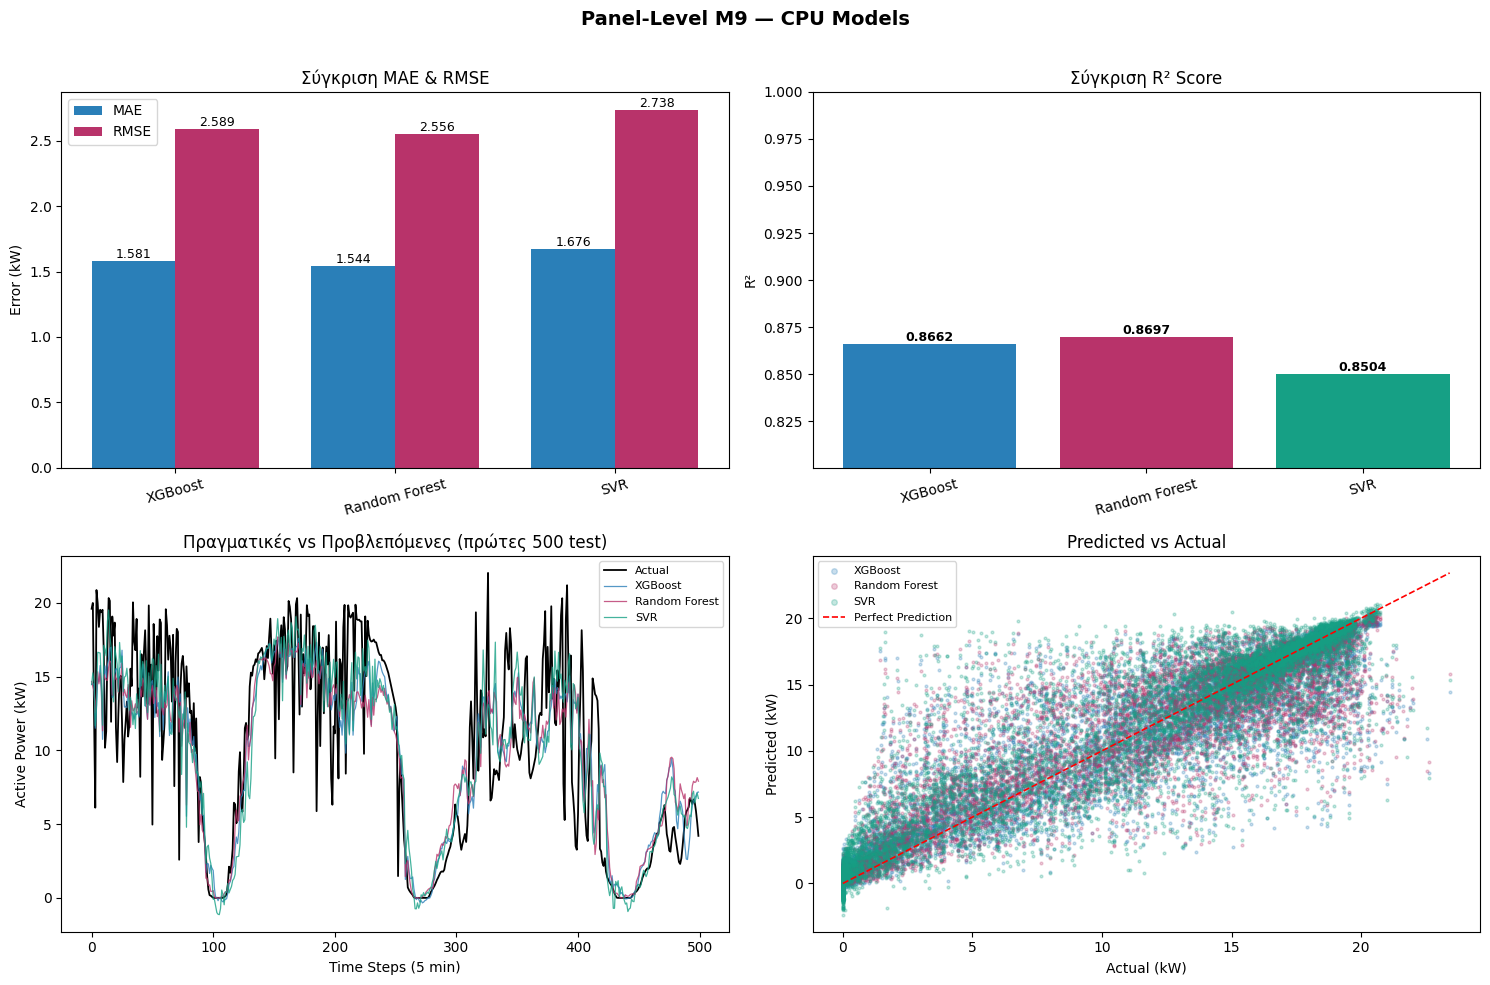

In [11]:
panel_figure(["XGBoost", "RandomForest", "SVR"], "Panel-Level M9 — CPU Models", "panel_m9_cpu.png")

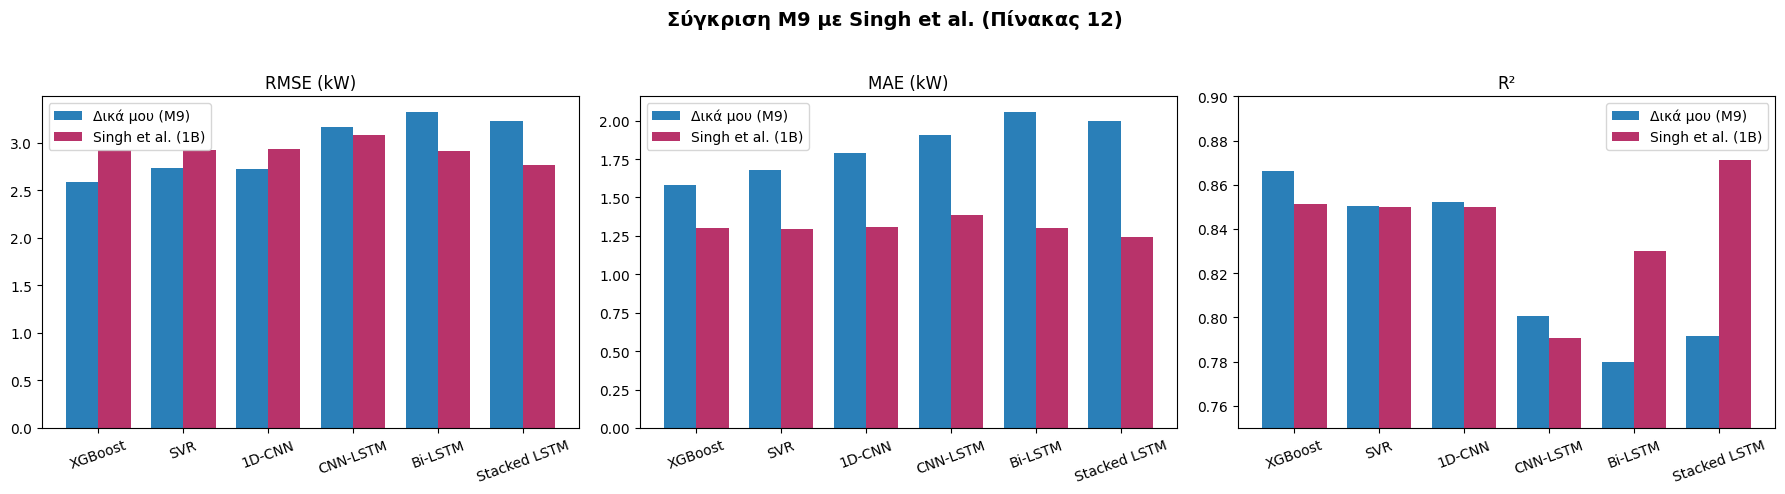

In [12]:
comparison_figure()